<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day10-cnns-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 10 — CNNs in code {.unnumbered}

This notebook has two parts. First, a small from-scratch demonstration of
*why* convolution gives translation equivariance/invariance -- a structural
property of a shared, sliding kernel, shown here on an **untrained** layer
(no training needed to see it: it comes from the architecture, not from
learning). Second, a real case study: the exact subcellular-localization
dataset and train/val/test split from Days 8-9, this time classified with a
**1D convolutional** network instead of the flat fully-connected one, so the
comparison across architectures is on identical data.

Adapted in part from Ekman et al.'s Chapter 7 notebook (`notebooks/ch07.ipynb`,
internal course material, not openly licensed -- see the sources note on the
book page), reworked here as a faster, from-scratch structural demonstration
rather than re-running its full CIFAR-10 training pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

## Part 1: why convolution gives translation equivariance (and, with pooling, invariance)

A 1D convolution slides the *same* small kernel across every position of its
input. If the input signal is shifted, the kernel sees the same local pattern,
just later (or earlier) -- so the output feature map should shift by exactly
the same amount. That is **equivariance**: `conv(shift(x)) == shift(conv(x))`
(up to the boundary, where the kernel runs off the edge). This is a property
of the architecture itself -- weight sharing -- and holds even for a
completely untrained, randomly-initialized kernel, which is what we use below
so there is no training involved in this demonstration at all.

In [2]:
conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=5, padding=2, bias=False)

# A toy signal: a single sharp "bump" at position 20 in a length-60 sequence.
length = 60
signal = torch.zeros(1, 1, length)
signal[0, 0, 20] = 1.0

shift = 10
shifted_signal = torch.zeros(1, 1, length)
shifted_signal[0, 0, 20 + shift] = 1.0

with torch.no_grad():
    out = conv(signal)[0, 0].numpy()
    out_shifted = conv(shifted_signal)[0, 0].numpy()

# Compare: shifting the OUTPUT of the original by `shift` positions should
# match the output computed from the ALREADY-shifted input (away from the
# boundary effects near the edges where the kernel runs off the sequence).
out_rolled = np.roll(out, shift)
interior = slice(10, 50)  # stay away from both edges
max_abs_diff = np.max(np.abs(out_rolled[interior] - out_shifted[interior]))
print(f"max |shift(conv(x)) - conv(shift(x))| over the interior region: {max_abs_diff:.2e}")
print("equivariant (matches to floating-point precision away from the edges):", max_abs_diff < 1e-6)

max |shift(conv(x)) - conv(shift(x))| over the interior region: 0.00e+00
equivariant (matches to floating-point precision away from the edges): True


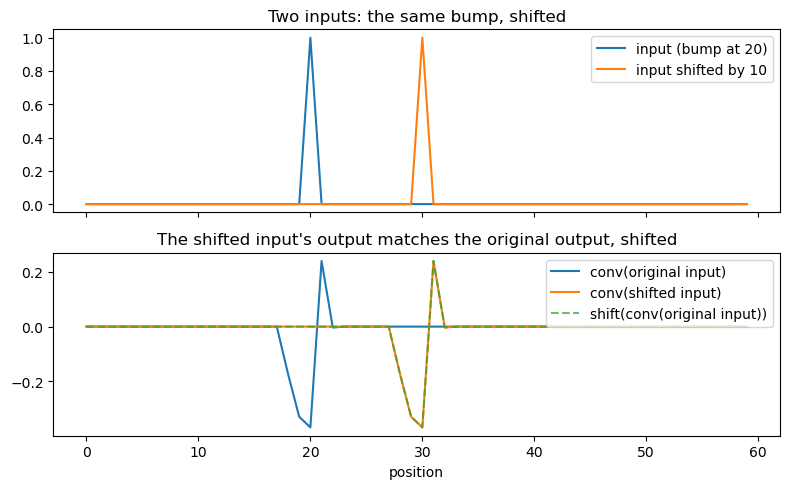

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(signal[0, 0].numpy(), label="input (bump at 20)")
axes[0].plot(shifted_signal[0, 0].numpy(), label=f"input shifted by {shift}")
axes[0].set_title("Two inputs: the same bump, shifted")
axes[0].legend()
axes[1].plot(out, label="conv(original input)")
axes[1].plot(out_shifted, label="conv(shifted input)")
axes[1].plot(out_rolled, "--", label="shift(conv(original input))", alpha=0.7)
axes[1].set_title("The shifted input's output matches the original output, shifted")
axes[1].legend()
axes[1].set_xlabel("position")
plt.tight_layout()
plt.savefig("../figs/day10-conv-equivariance.png", dpi=150)
plt.show()

**From equivariance to invariance.** Equivariance alone still leaves the bump
at a different position in the output feature map -- useful, but not yet
"the same answer regardless of position." **Global pooling** (taking the
max, or the mean, over the whole feature map) removes the position
information entirely: the *value* of the peak is preserved by shifting, so
its max is too, regardless of where it sits. That combination --
weight-shared convolution (equivariant) followed by global pooling
(position-independent) -- is exactly what gives a convolutional network
translation invariance, and it requires no training to exist as a structural
property of the architecture.

In [4]:
pooled_original = out.max()
pooled_shifted = out_shifted.max()
print(f"max-pooled output, original input:  {pooled_original:.6f}")
print(f"max-pooled output, shifted input:   {pooled_shifted:.6f}")
print("identical after pooling:", np.isclose(pooled_original, pooled_shifted))

max-pooled output, original input:  0.239905
max-pooled output, shifted input:   0.239905
identical after pooling: True


## Part 2: the subcellular-localization case study, this time with a 1D CNN

Same dataset, same encoding, same homology-aware train/val/test split as Days 8-9 (fetched
live from UniProt again here, with the same fixed random seeds, so it should
reproduce the same 700-protein, 5-class, 486/105/109 homology-aware split) -- but this time
the classifier is a 1D convolutional network over the sequence, instead of a
flat fully-connected one, directly demonstrating the "1D convolution over a
sequence" idea from the book page.

In [5]:
import re
import requests

UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))
    return rows

def is_unambiguous_single_location(location_text, target):
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip().rstrip(".")
        if top_term:
            terms.add(top_term)
    return terms == {target}

entries_by_class = {name: [] for name in CLASS_NAMES}
for name, code in UNIPROT_CLASSES.items():
    rows = fetch_uniprot(code, size=500)
    kept = [(acc, seq) for (acc, seq, loc) in rows if is_unambiguous_single_location(loc, name)]
    entries_by_class[name] = kept
    print(f"{name}: fetched {len(rows)}, unambiguous single-location {len(kept)}")

Cytoplasm: fetched 500, unambiguous single-location 424


Nucleus: fetched 500, unambiguous single-location 497


Mitochondrion: fetched 500, unambiguous single-location 140


Secreted: fetched 500, unambiguous single-location 488


Cell membrane: fetched 500, unambiguous single-location 338


In [6]:
N_PER_CLASS = min(len(v) for v in entries_by_class.values())
print("balancing every class to", N_PER_CLASS, "sequences")

rng = np.random.RandomState(0)
balanced_accs, balanced_seqs, balanced_labels = [], [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = entries_by_class[class_name]
    for i in rng.choice(len(pool), N_PER_CLASS, replace=False):
        balanced_accs.append(pool[i][0])
        balanced_seqs.append(pool[i][1])
        balanced_labels.append(class_idx)

print("total balanced dataset:", len(balanced_seqs), "sequences,", len(CLASS_NAMES), "classes")
print("(Day 8/9 reported 700 sequences, 140/class -- checking this matches)")

balancing every class to 140 sequences
total balanced dataset: 700 sequences, 5 classes
(Day 8/9 reported 700 sequences, 140/class -- checking this matches)


In [7]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded  # (SEQ_LEN, 20) -- NOT flattened this time, a CNN wants the 2D shape

X = np.stack([one_hot_encode(s) for s in balanced_seqs])       # (N, 150, 20)
X = X.transpose(0, 2, 1)                                        # (N, 20, 150): channels=amino acids, length=position
y = np.array(balanced_labels)
print("X shape:", X.shape, " (N, channels=20 amino acids, length=150 positions)")
print("y shape:", y.shape)

X shape: (700, 20, 150)  (N, channels=20 amino acids, length=150 positions)
y shape: (700,)


In [8]:
import os, shutil, subprocess, tempfile

# Day 8's homology-aware split: MMseqs2 clusters at 30% identity, whole clusters per split
CLUSTER_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/day08-subcell-mmseqs-30.tsv"
LOCAL_TSV = "data/day08-subcell-mmseqs-30.tsv"

def mmseqs_clusters(accs, seqs, min_seq_id=0.3):
    tmp = tempfile.mkdtemp()
    with open(f"{tmp}/in.fasta", "w") as f:
        for a, s in zip(accs, seqs):
            f.write(f">{a}\n{s}\n")
    subprocess.run(["mmseqs", "easy-cluster", f"{tmp}/in.fasta", f"{tmp}/clu", f"{tmp}/work",
                    "--min-seq-id", str(min_seq_id), "-c", "0.5", "-v", "1"],
                   check=True, stdout=subprocess.DEVNULL)
    pairs = [line.split("\t") for line in open(f"{tmp}/clu_cluster.tsv").read().split("\n") if line]
    shutil.rmtree(tmp)
    return {member: rep for rep, member in pairs}

def load_precomputed_clusters():
    text = open(LOCAL_TSV).read() if os.path.exists(LOCAL_TSV) else requests.get(CLUSTER_URL, timeout=30).text
    pairs = [line.split("\t") for line in text.strip().split("\n")[1:]]
    return {member: rep for rep, member in pairs}

if shutil.which("mmseqs"):
    member_to_rep = mmseqs_clusters(balanced_accs, balanced_seqs)
    print("clustered with local MMseqs2 (30% identity, 50% coverage)")
else:
    member_to_rep = load_precomputed_clusters()
    print("mmseqs not found -- loaded the precomputed MMseqs2 clustering")

# proteins missing from the clustering (e.g. if UniProt changed) become their own cluster
reps = [member_to_rep.get(a, a) for a in balanced_accs]
rep_ids = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_ids[r] for r in reps])
sizes = np.bincount(groups)
print(f"{len(y)} proteins -> {len(sizes)} clusters; "
      f"{(sizes > 1).sum()} clusters have more than one member ({sizes[sizes > 1].sum()} proteins), largest has {sizes.max()}")

def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    '''Assign whole clusters, in random order, to train/val/test: each cluster
    goes to the split furthest below its target share of that cluster's
    classes (ties broken at random). Returns three index arrays.'''
    rng = np.random.RandomState(seed)
    n_classes = y.max() + 1
    target = np.outer(fractions, np.bincount(y, minlength=n_classes))   # (3 splits, n_classes)
    have = np.zeros_like(target)
    assignment = {}
    for g in rng.permutation(np.unique(groups)):
        cls_counts = np.bincount(y[groups == g], minlength=n_classes)
        deficit = ((target - have) * (cls_counts > 0)).sum(axis=1) / target.sum(axis=1)
        best = np.flatnonzero(deficit == deficit.max())
        split = int(rng.choice(best))
        assignment[g] = split
        have[split] += cls_counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_h, va_h, te_h = homology_split(y, groups)
X_train, y_train = X[tr_h], y[tr_h]
X_val, y_val = X[va_h], y[va_h]
X_test, y_test = X[te_h], y[te_h]
print(f"train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")
print("(Day 8/9 reported 486 / 105 / 109 -- checking this matches)")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

clustered with local MMseqs2 (30% identity, 50% coverage)
700 proteins -> 551 clusters; 75 clusters have more than one member (224 proteins), largest has 11
train: 486   val: 105   test: 109
(Day 8/9 reported 486 / 105 / 109 -- checking this matches)


### A 1D-CNN classifier

Two convolutional layers (kernel size 7, i.e. each filter looks at a 7-residue
window) with ReLU and max-pooling, then global average pooling over the
remaining sequence length (making the classifier's decision insensitive to
*where* along the sequence a signal was detected -- exactly Part 1's
equivariance-then-pooling argument, now inside a real classifier), then a
linear layer to the 5 classes.

In [9]:
class LocalizationCNN(nn.Module):
    def __init__(self, n_classes=5, n_channels=20):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, padding=3)
        self.pool = nn.MaxPool1d(2)
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):                      # x: (batch, 20, 150)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = torch.adaptive_avg_pool1d(x, 1).squeeze(-1)   # global average pool -> (batch, 64)
        return self.classifier(x)               # raw logits, (batch, n_classes)


cnn_model = LocalizationCNN()
n_params = sum(p.numel() for p in cnn_model.parameters())
print(cnn_model)
print("total trainable parameters:", n_params)
print("(Day 8/9's flat MLP had ~192,389 parameters -- for comparison)")

LocalizationCNN(
  (conv1): Conv1d(20, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)
total trainable parameters: 19237
(Day 8/9's flat MLP had ~192,389 parameters -- for comparison)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_acc = 0.0
best_state = None
history = {"train_acc": [], "val_acc": []}

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

for epoch in range(100):
    cnn_model.train()
    optimizer.zero_grad()
    logits = cnn_model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    train_acc = accuracy(cnn_model, X_train_t, y_train_t)
    val_acc = accuracy(cnn_model, X_val_t, y_val_t)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}

cnn_model.load_state_dict(best_state)
print(f"best validation accuracy {best_val_acc:.3f} at epoch {best_epoch} of 100 (early-stopped, same practice as Day 9)")
print(f"final train accuracy at that epoch: {history['train_acc'][best_epoch]:.3f}")

best validation accuracy 0.600 at epoch 68 of 100 (early-stopped, same practice as Day 9)
final train accuracy at that epoch: 0.640


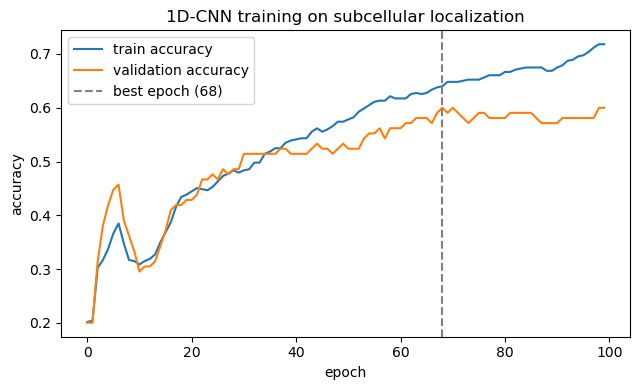

In [11]:
plt.figure(figsize=(6.5, 4))
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="validation accuracy")
plt.axvline(best_epoch, linestyle="--", color="gray", label=f"best epoch ({best_epoch})")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("1D-CNN training on subcellular localization")
plt.legend()
plt.tight_layout()
plt.savefig("../figs/day10-cnn-training-curve.png", dpi=150)
plt.show()

### Evaluating on the held-out test set, with the same metrics as Day 8/9

In [12]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, matthews_corrcoef
import torch.nn.functional as F

cnn_model.eval()
with torch.no_grad():
    test_logits = cnn_model(X_test_t)
    test_probs = F.softmax(test_logits, dim=1).numpy()
    test_preds = test_logits.argmax(dim=1).numpy()

cnn_test_acc = (test_preds == y_test).mean()
precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)
cnn_mcc = matthews_corrcoef(y_test, test_preds)
cnn_auroc = roc_auc_score(y_test, test_probs, multi_class="ovr", average="macro")

print(f"1D-CNN  test accuracy:  {cnn_test_acc:.3f}")
print(f"1D-CNN  macro F1:       {f1:.3f}")
print(f"1D-CNN  MCC:            {cnn_mcc:.3f}")
print(f"1D-CNN  macro AUROC:    {cnn_auroc:.3f}")
print()
print("For comparison, on the SAME homology-aware test set (Days 8-9):")
print("  flat MLP, untrained (Day 8, validation set): accuracy 0.181, macro F1 0.124, MCC -0.027, macro AUROC 0.474")
print("  flat MLP, trained, early-stopped (Day 9):    accuracy 0.514, macro F1 0.493, MCC 0.394, macro AUROC 0.831")
print("  logistic regression, no hidden layer (Day 9): accuracy 0.569,                 MCC 0.461, macro AUROC 0.849")

1D-CNN  test accuracy:  0.587
1D-CNN  macro F1:       0.586
1D-CNN  MCC:            0.485
1D-CNN  macro AUROC:    0.868

For comparison, on the SAME homology-aware test set (Days 8-9):
  flat MLP, untrained (Day 8, validation set): accuracy 0.181, macro F1 0.124, MCC -0.027, macro AUROC 0.474
  flat MLP, trained, early-stopped (Day 9):    accuracy 0.514, macro F1 0.493, MCC 0.394, macro AUROC 0.831
  logistic regression, no hidden layer (Day 9): accuracy 0.569,                 MCC 0.461, macro AUROC 0.849
